In [33]:
import pandas as pd

df = pd.read_csv("deepswe_20260709.csv")
df

,gpt-5.6-sol[max]
0,73%±3%
1,$8.39
2,60k
3,61
4,gpt-5.6-sol[xhigh]
...,...
204,gpt-5.6-luna[low]
205,2%±1%
206,$0.07
207,3.1k


In [34]:
# The source file stores each record as five lines instead of CSV columns.
values = [df.columns[0], *df.iloc[:, 0].tolist()]
fields_per_record = 5

if len(values) % fields_per_record:
    raise ValueError("Input does not contain complete five-field records")

df = pd.DataFrame(
    [values[i : i + fields_per_record] for i in range(0, len(values), fields_per_record)]
).set_index(0).T
df

# transform the data frame so the columns become rows and the rows become columns
df_transposed = df.T
df_transposed

# reset the index
df_transposed.reset_index(inplace=True)
# add column names ["model", "score", "cost", "out_tokens", "steps"]
df_transposed.columns = ["model", "score", "cost", "out_tokens", "steps"]

# split the "score" column on the +- symbol and move the second % to a new column "variance"
df_transposed[["score", "variance"]] = df_transposed["score"].str.split("±", expand=True)

# in "score" and "variance", strip the "%" symbol and make it an integer. In "cost" column, strip the $ symbol and make it a float.
df_transposed["score"] = df_transposed["score"].str.rstrip("%").astype(int)
df_transposed["variance"] = df_transposed["variance"].str.rstrip("%").astype(int)
df_transposed["cost"] = df_transposed["cost"].str.lstrip("$").astype(float)
df_transposed["out_tokens"] = df_transposed["out_tokens"].str.rstrip("k").astype(float)

# reorder the df columns by ["model", "score", "variance", "cost", "out_tokens", "steps"]
df_transposed = df_transposed[["model", "score", "variance", "cost", "out_tokens", "steps"]]

# set "model" as the index
df_transposed.set_index("model", inplace=True)

df_transposed

,score,variance,cost,out_tokens,steps
model,,,,,
gpt-5.6-sol[max],73,3,8.39,60.0,61
gpt-5.6-sol[xhigh],71,1,4.70,41.0,44
claude-fable-5[xhigh],70,3,13.41,80.0,68
claude-fable-5[max],70,4,21.63,119.0,88
gpt-5.6-terra[max],70,3,4.95,72.0,76
gpt-5.6-sol[high],69,1,3.47,28.0,37
claude-fable-5[high],69,1,9.18,57.0,59
gpt-5.6-luna[max],67,4,3.03,73.0,102
gpt-5.5[xhigh],67,6,7.23,46.0,82


In [35]:
# add a visual bar that starts from the left edge of the cell
df_transposed["visual_score"] = df_transposed["score"].apply(lambda x: "█" * (x // 2)).str.ljust(60, " ")

styled_df = (
    df_transposed.style
    .set_properties(subset=["visual_score"], **{"text-align": "left"})
    .set_table_styles(
        [
            {"selector": "th", "props": [("text-align", "left")]},
            {"selector": "td", "props": [("text-align", "left")]},
        ]
    )
)

styled_df

,score,variance,cost,out_tokens,steps,visual_score
model,,,,,,
gpt-5.6-sol[max],73,3,8.390000,60.000000,61,████████████████████████████████████
gpt-5.6-sol[xhigh],71,1,4.700000,41.000000,44,███████████████████████████████████
claude-fable-5[xhigh],70,3,13.410000,80.000000,68,███████████████████████████████████
claude-fable-5[max],70,4,21.630000,119.000000,88,███████████████████████████████████
gpt-5.6-terra[max],70,3,4.950000,72.000000,76,███████████████████████████████████
gpt-5.6-sol[high],69,1,3.470000,28.000000,37,██████████████████████████████████
claude-fable-5[high],69,1,9.180000,57.000000,59,██████████████████████████████████
gpt-5.6-luna[max],67,4,3.030000,73.000000,102,█████████████████████████████████
gpt-5.5[xhigh],67,6,7.230000,46.000000,82,█████████████████████████████████


In [36]:
df_cost = df_transposed.sort_values("cost")

styled_df = (
    df_cost.style
    .set_properties(subset=["visual_score"], **{"text-align": "left"})
    .set_table_styles(
        [
            {"selector": "th", "props": [("text-align", "left")]},
            {"selector": "td", "props": [("text-align", "left")]},
        ]
    )
)

styled_df

,score,variance,cost,out_tokens,steps,visual_score
model,,,,,,
gpt-5.6-luna[low],2,1,0.070000,3.100000,12,█
gpt-5.6-luna[medium],11,1,0.220000,8.200000,24,█████
gpt-5.6-terra[low],24,1,0.430000,8.600000,21,████████████
gpt-5.6-terra[medium],35,3,0.580000,12.000000,25,█████████████████
gpt-5.6-luna[high],44,3,0.780000,26.000000,49,██████████████████████
gpt-5.6-sol[low],45,2,1.070000,11.000000,23,██████████████████████
gpt-5.6-terra[high],54,4,1.130000,22.000000,34,███████████████████████████
gpt-5.5[low],27,2,1.200000,9.400000,28,█████████████
gpt-5.6-luna[xhigh],57,2,1.540000,45.000000,71,████████████████████████████


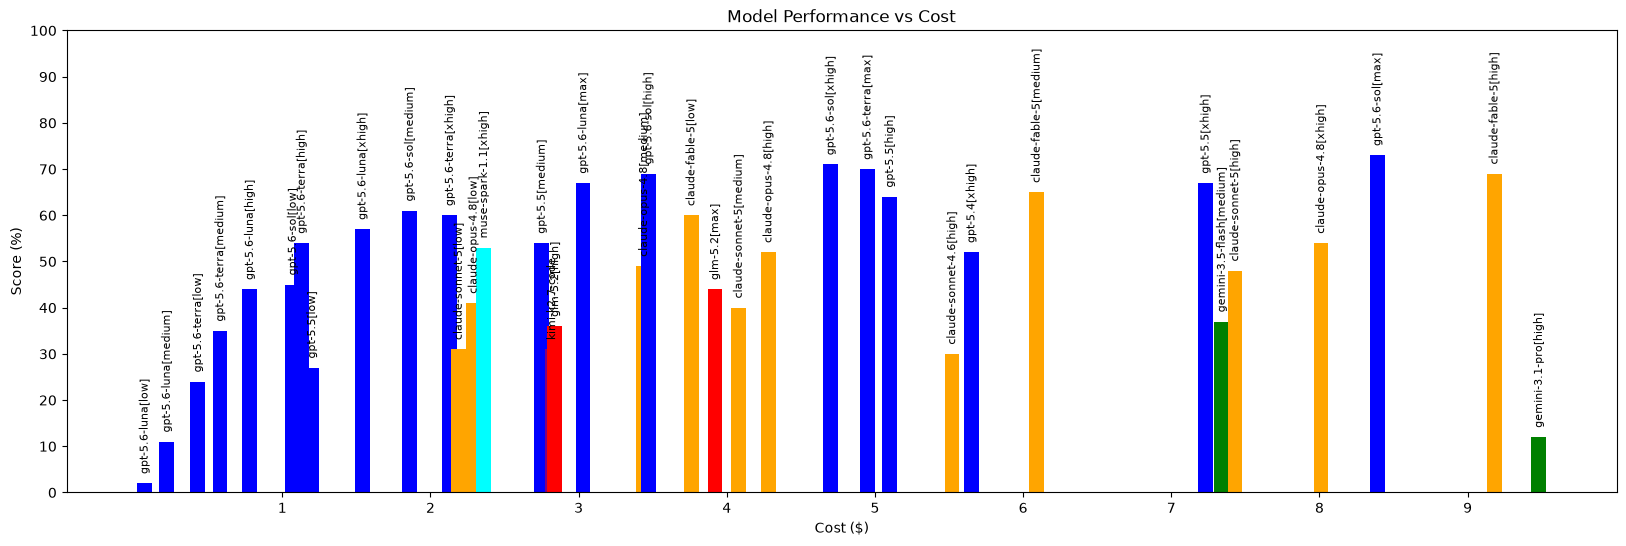

In [49]:
# plot the prior cell as a bar graph with cost on the x axis and score on the y axis. The x axis should be labeled "Cost ($)" and the y axis should be labeled "Score (%)". The title of the graph should be "Model Performance vs Cost". The graph should be saved as a PNG file named "model_performance_vs_cost.png".
# the bars should be colored by the model prefix (e.g. "claude" models should be orange, "gpt" models should be blue). Build a legend that maps the model prefixes to colors. The legend should be placed in the upper left corner of the graph.
import matplotlib.pyplot as plt

plot_df = df_cost.reset_index()
# drop any lines with cost > 10.00
plot_df = plot_df[plot_df["cost"] <= 10.00]

plt.figure(figsize=(20, 6))
color_map = {"claude": "orange", "gpt": "blue", "gemini":"green", "muse":"cyan", "glm":"red", "kimi":"purple"}
colors = [color_map[model.split("-")[0]] for model in plot_df["model"]]

# the bars should be narrow and the width of the bars should be 0.5. The x axis should be scaled to fit the data and the y axis should be scaled to fit the data. The x axis should have ticks at every $10 increment and the y axis should have ticks at every 10% increment.

# there should be diagonal labels above the top of the bars that show the model name and the score. The labels should be rotated 45 degrees and should be placed above the bars. The labels should be in a smaller font size than the axis labels. The labels should be in black color.
for i, row in plot_df.iterrows():
    plt.text(
        row["cost"],
        row["score"] + 2,
        f"{row['model']}",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=8,
        color="black",
    )
plt.bar(plot_df["cost"], plot_df["score"], color=colors, width=0.1)
plt.xticks(range(1, int(plot_df["cost"].max()) + 1, 1))
plt.yticks(range(0, 101, 10))
plt.xlabel("Cost ($)")
plt.ylabel("Score (%)")
plt.title("Model Performance vs Cost")
plt.savefig("model_performance_vs_cost.png")

In [ ]:
df_variance = df_transposed.sort_values("variance")

styled_df = (
    df_variance.style
    .set_properties(subset=["visual_score"], **{"text-align": "left"})
    .set_table_styles(
        [
            {"selector": "th", "props": [("text-align", "left")]},
            {"selector": "td", "props": [("text-align", "left")]},
        ]
    )
)

styled_df